In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [32]:
df = pd.read_csv('../Data/Telco_Cusomer_Churn.csv')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors= 'coerce')

In [35]:
df.drop(columns=['customerID'], inplace=True)

In [39]:
df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [44]:
df['TotalCharges'].fillna(0, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_49584\171940771.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [46]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [62]:
X_numerico = pd.get_dummies(X, drop_first=True)

In [50]:
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_numerico,y, test_size=0.2,random_state=42)

In [52]:
y.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [53]:
print(X_numerico.shape)

(7043, 30)


In [63]:
X_numerico.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
predicciones = rf.predict(X_test)

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, predicciones))

print(confusion_matrix(y_test, predicciones))

print(accuracy_score(y_test, predicciones))

              precision    recall  f1-score   support

          No       0.82      0.91      0.86      1036
         Yes       0.64      0.44      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.67      0.69      1409
weighted avg       0.77      0.78      0.77      1409

[[943  93]
 [210 163]]
0.7849538679914834


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [None, 10, 20],         
    'min_samples_split': [2, 5, 10]     
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

print("Mejores parámetros encontrados:", grid_search.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores parámetros encontrados: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


In [71]:
param_grid_ampliado = {
    'n_estimators': [250, 300, 350, 400],
    'max_depth': [10, 12, 15],             
    'min_samples_split': [12, 15, 17, 20]  
}

grid_search_ampliado = GridSearchCV(estimator=rf, param_grid=param_grid_ampliado, cv=5, n_jobs=-1, verbose=1)

grid_search_ampliado.fit(X_train, y_train)

print("Nuevos mejores parámetros encontrados:", grid_search_ampliado.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Nuevos mejores parámetros encontrados: {'max_depth': 15, 'min_samples_split': 20, 'n_estimators': 300}


In [72]:
predicciones_iniciales = grid_search.predict(X_test)

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test, predicciones_iniciales))

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, predicciones_iniciales))

print("\n--- EXACTITUD (ACCURACY) ---")
print(accuracy_score(y_test, predicciones_iniciales))

predicciones_optimizadas = grid_search_ampliado.predict(X_test)

print("--- MATRIZ DE CONFUSIÓN ---")
print(confusion_matrix(y_test, predicciones_optimizadas))

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, predicciones_optimizadas))

print("\n--- EXACTITUD (ACCURACY) ---")
print(accuracy_score(y_test, predicciones_optimizadas))

--- MATRIZ DE CONFUSIÓN ---
[[953  83]
 [182 191]]

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

          No       0.84      0.92      0.88      1036
         Yes       0.70      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- EXACTITUD (ACCURACY) ---
0.8119233498935415
--- MATRIZ DE CONFUSIÓN ---
[[952  84]
 [183 190]]

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

          No       0.84      0.92      0.88      1036
         Yes       0.69      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- EXACTITUD (ACCURACY) ---
0.8105039034776437


In [ ]:
modelo_rf_balanceado = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced'
)

param_grid_balanceado = {
    'n_estimators': [200],
    'max_depth': [10],
    'min_samples_split': [10]
}

grid_search_balanceado = GridSearchCV(
    estimator=modelo_rf_balanceado, 
    param_grid=param_grid_balanceado, 
    cv=5, 
    n_jobs=-1
)
grid_search_balanceado.fit(X_train, y_train)

predicciones_balanceadas = grid_search_balanceado.predict(X_test)

print("--- MATRIZ DE CONFUSIÓN (BALANCEADA) ---")
print(confusion_matrix(y_test, predicciones_balanceadas))

print("\n--- REPORTE DE CLASIFICACIÓN (BALANCEADO) ---")
print(classification_report(y_test, predicciones_balanceadas))

--- MATRIZ DE CONFUSIÓN (BALANCEADA) ---
[[815 221]
 [ 81 292]]

--- REPORTE DE CLASIFICACIÓN (BALANCEADO) ---
              precision    recall  f1-score   support

          No       0.91      0.79      0.84      1036
         Yes       0.57      0.78      0.66       373

    accuracy                           0.79      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.79      0.79      1409



C:\Users\USER\AppData\Local\Temp\ipykernel_49584\344389992.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(10), palette='viridis')


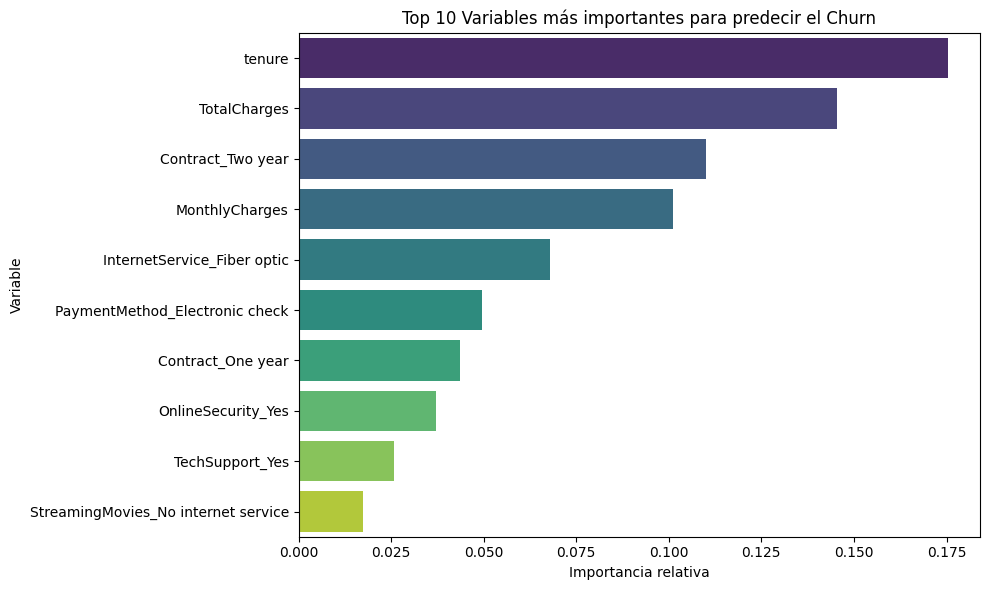

                               Variable  Importancia
1                                tenure     0.175281
3                          TotalCharges     0.145291
25                    Contract_Two year     0.109986
2                        MonthlyCharges     0.101119
10          InternetService_Fiber optic     0.067916
28       PaymentMethod_Electronic check     0.049466
24                    Contract_One year     0.043695
13                   OnlineSecurity_Yes     0.037253
19                      TechSupport_Yes     0.025659
22  StreamingMovies_No internet service     0.017429


In [75]:
importancias = grid_search_balanceado.best_estimator_.feature_importances_

df_importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(10), palette='viridis')
plt.title('Top 10 Variables más importantes para predecir el Churn')
plt.xlabel('Importancia relativa')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

print(df_importancias.head(10))

In [76]:
top_15_variables = df_importancias.head(15)['Variable'].tolist()

X_train_top = X_train[top_15_variables]
X_test_top = X_test[top_15_variables]

modelo_rf_purificado = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

modelo_rf_purificado.fit(X_train_top, y_train)

predicciones_purificadas = modelo_rf_purificado.predict(X_test_top)

print("--- MATRIZ DE CONFUSIÓN (MODELO PURIFICADO - TOP 15) ---")
print(confusion_matrix(y_test, predicciones_purificadas))

print("\n--- REPORTE DE CLASIFICACIÓN (MODELO PURIFICADO - TOP 15) ---")
print(classification_report(y_test, predicciones_purificadas))

--- MATRIZ DE CONFUSIÓN (MODELO PURIFICADO - TOP 15) ---
[[814 222]
 [ 82 291]]

--- REPORTE DE CLASIFICACIÓN (MODELO PURIFICADO - TOP 15) ---
              precision    recall  f1-score   support

          No       0.91      0.79      0.84      1036
         Yes       0.57      0.78      0.66       373

    accuracy                           0.78      1409
   macro avg       0.74      0.78      0.75      1409
weighted avg       0.82      0.78      0.79      1409



In [77]:
top_10_variables = df_importancias.head(10)['Variable'].tolist()

X_train_top10 = X_train[top_10_variables]
X_test_top10 = X_test[top_10_variables]

modelo_rf_top10 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

modelo_rf_top10.fit(X_train_top10, y_train)

probabilidades = modelo_rf_top10.predict_proba(X_test_top10)[:, 1]

umbral = 0.65
predicciones_umbral = np.where(probabilidades >= umbral, 'Yes', 'No')

print(f"--- MATRIZ DE CONFUSIÓN (TOP 10 + UMBRAL {umbral}) ---")
print(confusion_matrix(y_test, predicciones_umbral))

print(f"\n--- REPORTE DE CLASIFICACIÓN (TOP 10 + UMBRAL {umbral}) ---")
print(classification_report(y_test, predicciones_umbral))

--- MATRIZ DE CONFUSIÓN (TOP 10 + UMBRAL 0.65) ---
[[924 112]
 [151 222]]

--- REPORTE DE CLASIFICACIÓN (TOP 10 + UMBRAL 0.65) ---
              precision    recall  f1-score   support

          No       0.86      0.89      0.88      1036
         Yes       0.66      0.60      0.63       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.75      1409
weighted avg       0.81      0.81      0.81      1409



## SE LLEVARÁ A XGBOOST!